# Lab 6 Forests


### Submission And Assignment Instructions
Submit your `Lab6_lastname_firstname.pdf` file on canvas with your answers clearly marked (✅) and code commented. Skeleton code and/or comments are provided throughout to help you.

Formatting Notes:
- ❓Questions you must answer or tasks are marked with a "❓"
- ✅ Answers you should give are marked with "✅ Answer:"
- *Helpful hints are usually given in italics*
- Code you need to write is marked with `## ❓YOUR CODE HERE`
  - ⭐ Bonus questions are marked with a "⭐"
  - 🍓 Bonus answers are marked with a "🍓"

**Please don't erase ANY of these markings!** They're to help the TAs find your answers and code as much as they're to help you find the questions.

# Section 1: Math

❓ Given a dataset, determine the fraction of observations that will be used to train a random forest model.

Hint: In a Random Forest, each tree is trained on a sample drawn with replacement from the dataset containing n datapoints. To determine the fraction of observations used, think about the probability that an observation is not selected in one draw, and extend this to the case where you draw n times - since most Random Forest implementations will use the original dataset size n to determine the dataset size for every tree. As the dataset size grows large (i.e., n -> infinity), use limits to estimate the probability of a datapoint to be not included.

✅ Answer:

Each tree draws n samples with replacement from n data points.

- Probability a given point is not picked in one draw: $1 - \frac{1}{n}$
- Probability it is never picked in n draws: $\left(1 - \frac{1}{n}\right)^n$
- As $n \to \infty$: $\lim_{n\to\infty}\left(1 - \frac{1}{n}\right)^n = e^{-1} \approx 0.368$

So about 36.8% of points are left out of each tree (the out-of-bag samples), and the fraction of observations used to train each tree is $1 - e^{-1} \approx 0.632$


# Section 2: From one tree, to one forest

Decision trees are known for their low bias, but this comes at the cost of high variance, making them prone to overfitting. Random Forest is designed to address this issue by combining multiple decision trees using bagging, which helps reduce variance while maintaining low bias.

Let's find out if this claim holds true!

## 2.1: Data preparation

❓ Generate a dataset with the following specifications:

* X: An array of 100 evenly spaced values in the range [-10, 10].
* Y: The tanh function $\left(\frac{e^{x}-e^{-x}}{e^{x}+e^{-x}} \right)$ applied to each value in X.
* Y_noise: For each value in Y, add random noise sampled from a normal distribution with a mean of 0 and a standard deviation of 0.1.

Within one figure, visualize the relationships of X and Y_noise using scattered dots, and X and Y using continous lines.

**Please include necessary figure elements (axis labels, legend).**

In [69]:
# load dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## please write your code below
np.random.seed(42)

# generate synthetic data
X = np.linspace(-10, 10, 100)

# write tanh function
Y = np.tanh(X)
YNoise = Y + np.random.normal(0, 0.1, len(X))

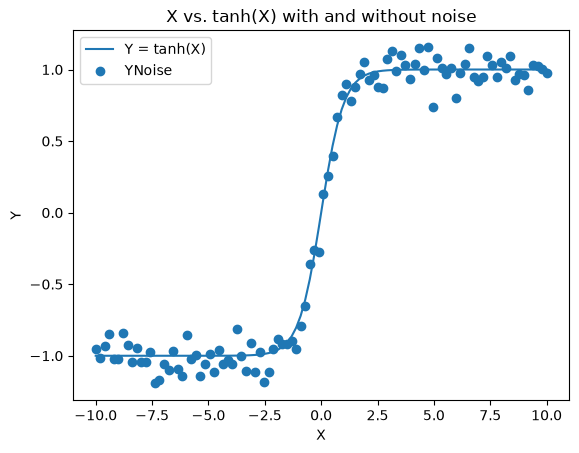

In [70]:
# visualization
## please write your code below
plt.plot(X, Y, label='Y = tanh(X)')
plt.scatter(X, YNoise, label='YNoise')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('X vs. tanh(X) with and without noise')
plt.legend()
plt.show()

## 2.2: Model training

❓ Using X and Y_noise, build a decision tree regressor and a random forest regressor (of 10 trees). Keep the default model settings.

Plotting: Overlay the model predictions for **X_pred**, an array of 500 evenly spaced values within the range [-10, 10], as continuous lines onto the existing figure.

**Please include necessary figure elements (axis labels, legend).**

In [ ]:
# import models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# define predicted range, X_pred
XTrain = X.reshape(-1, 1)
YTrain = YNoise
XPred = np.linspace(-10, 10, 500).reshape(-1, 1)

# model training
tree = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=10, random_state=42)
tree.fit(XTrain, YTrain)
rf.fit(XTrain, YTrain)
yTreePred = tree.predict(XPred)
yRfPred = rf.predict(XPred)

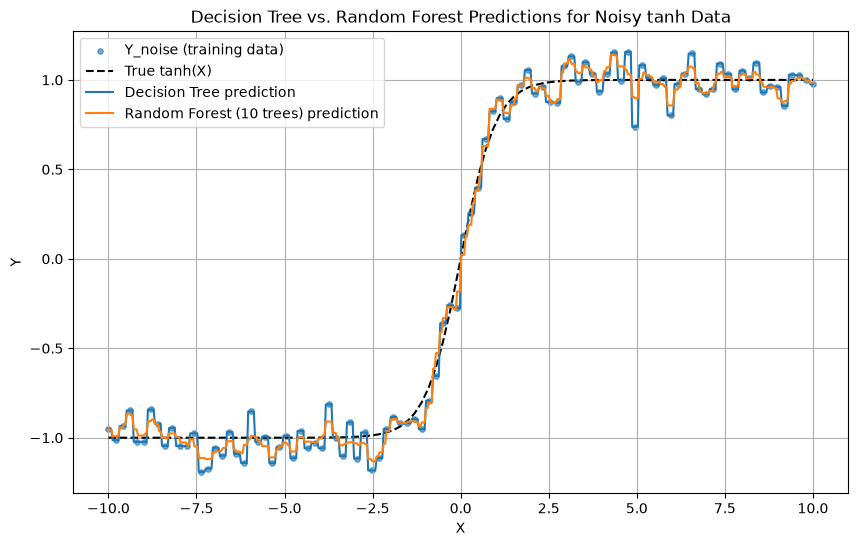

In [ ]:
# visualization
## please write your code below
plt.figure(figsize=(10, 6))
plt.scatter(X, YNoise, s=15, alpha=0.6, label='Y_noise (training data)')
plt.plot(X, Y, 'k--', label='True tanh(X)')
plt.plot(XPred, yTreePred, label='Decision Tree prediction')
plt.plot(XPred, yRfPred, label='Random Forest (10 trees) prediction')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Decision Tree vs. Random Forest Predictions for Noisy tanh Data')
plt.legend()
plt.grid(True)
plt.show()

❓ Based on the figure above, compare and contrast predictions of the two model.

✅ Answer: Both models capture the overall S-shape of tanh, but both also fit the noise. This can be seen by how their curves are step-like and follow individual noisy points, especially on the flat tails where the true value is a constant ±1. The single decision tree has the largest spikes because it memorizes every training point exactly, including outliers (high variance). The random forest averages 10 trees grown on different bootstrap samples. Therefore, many of those spikes partially cancel and its curve stays closer to the true tanh. The two models have similar (low) bias, and the forest's advantage is lower variance.

## 2.3: Model evaluation and optimization

The sigmoid function illustrates a clean and ideal relationship between dependent and independent variables, whereas Y_noise serves as a more realistic example of data that is accompanied by noise.

❓ Which model (decision tree or random forest) is more likely to accurately capture the sigmoid relationship? Prove your statement quantitatively using MAE, MSE, RMSE and $R^{2}$.

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# calculate true values on tanh
yTrue=np.tanh(XPred.ravel())
yTree=yTreePred.ravel()
yRf=yRfPred.ravel()

# model evaluation
treeMAE=mean_absolute_error(yTrue, yTree)
treeMSE=mean_squared_error(yTrue, yTree)
treeRMSE=np.sqrt(treeMSE)
treeR2=r2_score(yTrue, yTree)

rfMAE=mean_absolute_error(yTrue, yRf)
rfMSE=mean_squared_error(yTrue, yRf)
rfRMSE=np.sqrt(rfMSE)
rfR2=r2_score(yTrue, yRf)

In [74]:
# summarize results
print("Decision Tree vs True tanh:")
print(f" MAE = {treeMAE:.4f}")
print(f" MSE = {treeMSE:.4f}")
print(f" RMSE= {treeRMSE:.4f}")
print(f" R^2 = {treeR2:.4f}")
print("\nRandom Forest (10 trees) vs True tanh:")
print(f" MAE = {rfMAE:.4f}")
print(f" MSE = {rfMSE:.4f}")
print(f" RMSE= {rfRMSE:.4f}")
print(f" R^2 = {rfR2:.4f}")

# display the tabular summary
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest (10 trees)"],
    "MAE": [treeMAE, rfMAE],
    "MSE": [treeMSE, rfMSE],
    "RMSE": [treeRMSE, rfRMSE],
    "R^2": [treeR2, rfR2]
})
print(results)

Decision Tree vs True tanh:
 MAE = 0.0734
 MSE = 0.0086
 RMSE= 0.0928
 R^2 = 0.9904

Random Forest (10 trees) vs True tanh:
 MAE = 0.0530
 MSE = 0.0044
 RMSE= 0.0660
 R^2 = 0.9952
                      Model       MAE      MSE      RMSE       R^2
0             Decision Tree  0.073396  0.00861  0.092791  0.990435
1  Random Forest (10 trees)  0.052993  0.00436  0.066033  0.995156


✅ Explain your results: The random forest is more likely to capture the true tanh relationship, and it beats the single tree on every metric when both are compared to the noise-free curve: MAE 0.053 vs 0.073, MSE 0.0044 vs 0.0086, RMSE 0.066 vs 0.093, and R² 0.9952 vs 0.9904. The forest's MSE is about half the tree's. Because MSE squares errors, this shows the forest removed most of the large, noise-driven spikes from the tree. Both models have very high R^2, so neither is fully bad, and the gap reflects how much training noise each model fit. This supports the claim that bagging reduces variance while keeping bias low.

❓ Are there ways to improve your random forest model? Please give an example. *Write code to show that your idea is an improvement to the model.*

In [75]:
## please write your code below
rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf2.fit(XTrain, YTrain)
yRf2 = rf2.predict(XPred).ravel()

rf3 = RandomForestRegressor(n_estimators=100, min_samples_leaf=2, random_state=42)
rf3.fit(XTrain, YTrain)
yRf3 = rf3.predict(XPred).ravel()

# calculate true values
yTrue = np.tanh(XPred.ravel())

# model evaluation
def metrics(name, yHat):
    MSE = mean_squared_error(yTrue, yHat)
    return {"Model": name,
            "MAE": mean_absolute_error(yTrue, yHat),
            "MSE": MSE,
            "RMSE": np.sqrt(MSE),
            "R^2": r2_score(yTrue, yHat)}

# summarize results
# display the tabular summary
results = pd.DataFrame([
    metrics("Random Forest (10 trees)", yRf),
    metrics("Random Forest (100 trees)", yRf2),
    metrics("Random Forest (100 trees, min_samples_leaf=2)", yRf3),
])
print(results.to_string(index=False))

                                        Model      MAE      MSE     RMSE      R^2
                     Random Forest (10 trees) 0.052993 0.004360 0.066033 0.995156
                    Random Forest (100 trees) 0.050200 0.003948 0.062834 0.995614
Random Forest (100 trees, min_samples_leaf=2) 0.043689 0.002881 0.053678 0.996799


✅ Explain your results: Increasing from 10 to 100 trees gave a small improvement (RMSE from 0.066 to 0.063), because averaging more trees reduces the variance of the average, with diminishing returns. It does not stop each individual tree from overfitting.

It was better to regularize the trees themselves. With only one feature, a random forest cannot decorrelate its trees by sampling features, so every tree grows until each leaf holds a single noisy point. Requiring at least 2 samples per leaf keeps trees from being specific to individual noise points, cutting RMSE to 0.054 and raising R^2 to 0.9968.

# Section 3: The real world is imbalanced, and filled with uncertainty

## Quick readings

#### **Molecule Representation - SMILES**

In chemoinformatics, chemical structures are most commonly represented in SMILES (Simplified Molecular Input Line Entry System), which is a text-based way to specify atoms, bonds, and connectivity.

For example, ethanol (C$_2$H$_5$OH) can be simply written as "CCO", while bigger molecules like caffeine (C$_8$H$_{10}$N$_4$O$_2$) has more complex representation "CN1C=NC2=C(N1C(=O)N(C(=O)N2C)C)C(=O)N(C)C".



#### **Molecule Featurization**

While SMILES facilitates communication between chemists and computers, it does not capture the chemical knowledge that a model can learn. To address this, various algorithms and tools have been developed to featurize a molecule from its SMILES representation into numbers that capture the properties of molecules.

For instance, [RDKit](https://www.rdkit.org/docs/source/rdkit.Chem.Descriptors.html) offers a convenient interface that converts a SMILES string into a series of numerical values, capturing different aspects of the molecule's properties, such as molecular weight, number of hydrogen bond donors, and more.

## 3.1 Data preparation

Drug development is a multi-step process, and many candidates fail in clinical research due to toxicity, even if they meet efficacy requirements.

This dataset you will work on includes drugs that are associated with both failures due to toxicity and successful trials.

We here provide an example of featurizing (digitalizing) molecules using [RDKit descriptors](https://www.rdkit.org/docs/source/rdkit.Chem.Descriptors.html), which describe the given molecule using one of over 200 molecular properties.

In [76]:
%%capture
## examplary codes for featurizing molecules using RDKit descriptors
# install rdkit and import packages
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors
import math
import numpy as np
import pandas as pd

# define core function
descr = Descriptors._descList
feat_name = [i[0] for i in descr]
feat_calc = [i[1] for i in descr]

def describe_mol(smile_input):
  mol = Chem.MolFromSmiles(smile_input)
  calc_values = []
  for calc in feat_calc:
    value = calc(mol)
    if value > np.finfo(np.float32).max: # postprocess descriptors for freak large values
      value = np.finfo(np.float32).max
    elif math.isnan(value):
      value = np.float32(0.0)
    else:
      value = np.float32(value)
    calc_values.append(value)
  return calc_values

In [77]:
 # use aspirin as an example
exampleSmiles = 'CC(=O)OC1=CC=CC=C1C(=O)O'
exampleFeat = describe_mol(exampleSmiles)

❓ 3.1 How many distinct descriptors did you just calculate for aspirin? What is the 105-th descriptor's name? What does it mean, and what is the corresponding value of aspirin?

In [78]:
## please write your code below
n_desc=len(feat_name)
print(f"There are {n_desc} distinct descriptor")
print(f"The 105th descriptor is {feat_name[104]}")
print(f'The 105th descriptor value for aspirin is: {example_feat[104]}')

There are 217 distinct descriptor
The 105th descriptor is VSA_EState9
The 105th descriptor value for aspirin is: 0.0


✅ Answer: Calculated that there are 217 distinct descriptors for aspirin. The 105th descriptor (index 104) is VSA_EState9. The VSA_EState descriptors bin a molecule's atoms by their van der Waals surface area (VSA) contribution and sum the atoms' electrotopological state (EState) indices within each bin. RDKit documents VSA_EState9 as the bin 7.00 ≤ x < 11.00. Aspirin's value is 0.0, meaning none of its atoms have a VSA contribution in that range.

## 3.2 Sampling

We have introduced the idea of "imbalanced data" and associated potential issues. Now let's find out how we can mitigate it by using simple data balancing techniques.

In [79]:
# from google.colab import files
import pandas as pd

# training data
#train_data = files.upload()

#for fn in train_data.keys():
  #print('User uploaded file "{name}" with length {length} bytes'.format(
      #name=fn, length=len(train_data[fn])))

# test data
#test_data = files.upload()

#for fn in test_data.keys():
  #print('User uploaded file "{name}" with length {length} bytes'.format(
      #name=fn, length=len(test_data[fn])))

❓ By looking at your training data (provided), what is the ratio of data points with positive and negative labels? What does this ratio signify, and what potential issues could arise?

In [80]:
## please write your code below
df = pd.read_csv('train.csv')
counts = df['Y'].value_counts( )
neg = counts.get(0, 0)
pos = counts.get(1, 0)
print(f'Negative =', neg)
print(f'Positive =', pos)
print(f'Positive to negative ratio = {pos/neg}')

Negative = 955
Positive = 79
Positive to negative ratio = 0.08272251308900523


✅ Explain your results: The training set has 79 positives and 955 negatives, a positive-to-negative ratio of about 0.083 (roughly 1:12; only 7.6% of drugs are positive). This means the dataset is heavily imbalanced. A model trained on it sees mostly negatives, so it tends to favor predicting the majority (negative) class and under-predict the toxic class, (the class we care about). Accuracy also becomes misleading because a model that always predicts "negative" would score about 92% accuracy just by chance.

❓ What about your test data (provided)? Is it balanced or imbalanced?

In [81]:
## please write your code below
df1 = pd.read_csv('ext_test.csv')
counts = df1['Y'].value_counts()
neg1 = counts.get(0, 0)
pos1 = counts.get(1, 0)
print(f'Negative =', neg1)
print(f'Positive =', pos1)
print(f'Positive to negative ratio = {pos1/neg1}')

Negative = 411
Positive = 33
Positive to negative ratio = 0.08029197080291971


✅ Explain your results: The test set has 33 positives and 411 negatives, a ratio of about 0.080, so it is also imbalanced, with nearly the same class distribution as the training set. Because of this, a model biased toward the majority class will still look good on plain accuracy. With only 33 positives, metrics like F1 are also sensitive to just a few molecules.

❓ First, build a random forest model with 100 trees and a random state set to 42 using the provided training dataset. Then, evaluate your model using the test dataset. Please report the following metrics:

*   Accuracy
*   Balanced Accuracy
*   ROC AUC
*   F1 score

In [82]:
# load dependencies
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, f1_score

# please write your code below
trainDf = pd.read_csv('train.csv')
testDf = pd.read_csv('ext_test.csv')
XTrain = pd.DataFrame([describe_mol(smile) for smile in trainDf["Drug"]])
yTrain = trainDf["Y"]
XTest = pd.DataFrame([describe_mol(smile) for smile in testDf["Drug"]])
yTest = testDf["Y"]
rf3=RandomForestClassifier(n_estimators=100, random_state=42)
rf3. fit(XTrain, yTrain)
yPred=rf3. predict (XTest)
yProb =rf3. predict_proba(XTest)[:, 1]
acc = accuracy_score (yTest, yPred)
bacc = balanced_accuracy_score (yTest, yPred)
auc = roc_auc_score (yTest, yProb)
f1 = f1_score(yTest, yPred)
print("Accuracy:", acc)
print("Balanced Accuracy:", bacc)
print("ROC AUC:", auc)
print("F1 score:", f1)

Accuracy: 0.9279279279279279
Balanced Accuracy: 0.570891395708914
ROC AUC: 0.8825112438251125
F1 score: 0.23809523809523808


Although having more data is generally advantageous for model training, imbalanced data can introduce bias that adversely affects model performance.

Try applying the downsampling approach using [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.utils.resample.html) to see how it impacts your model's performance on the test dataset.

Note: To ensure that your results are reproducible, set the `random_state` parameter to 42.

In [83]:
# load dependencies
from sklearn.utils import resample

df0 = trainDf[trainDf["Y"] == 0]
df1 = trainDf[trainDf["Y"] == 1]

dfNegDownsamp = resample(
    df0,
    replace=False,
    n_samples=len(df1),
    random_state=42
)

trainBal = pd.concat([dfNegDownsamp, df1])

# Create X_train from applying describe_mol to all rows of train_df
XTrain = pd.DataFrame([
    describe_mol(smile) for smile in trainBal["Drug"]
])

yTrain = trainBal["Y"]

XTest = pd.DataFrame([
    describe_mol(smile) for smile in testDf["Drug"]
])

yTest = testDf["Y"]

rf4 = RandomForestClassifier(n_estimators=100, random_state=42)
rf4.fit(XTrain, yTrain)

yPred = rf4.predict(XTest)
yProb = rf4.predict_proba(XTest)[:, 1]

acc = accuracy_score(yTest, yPred)
bacc = balanced_accuracy_score(yTest, yPred)
auc = roc_auc_score(yTest, yProb)
f1 = f1_score(yTest, yPred)

print("Accuracy:", acc)
print("Balanced Accuracy:", bacc)
print("ROC AUC:", auc)
print("F1 score:", f1)

Accuracy: 0.7882882882882883
Balanced Accuracy: 0.8020349480203495
ROC AUC: 0.8843544938435449
F1 score: 0.36486486486486486


❓ How do these metrics change? Does the change indicate that the model is improving or getting worse?

✅ Answer:
Accuracy dropped, but balanced accuracy and F1 rose sharply. The original model's 0.928 accuracy barely beats predicting "negative" for everything (411/444 = 0.926), and its balanced accuracy of 0.571 shows it was nearly blind to the toxic class. After downsampling, the model catches most toxic drugs (recall of about 0.82, implied by the metrics), so for the goal of flagging toxic candidates the model is improving.

However, ROC AUC is essentially unchanged, so the model's ability to rank molecules did not improve and downsampling mainly shifted the effective decision threshold toward predicting "toxic." This comes at the cost of precision because the metrics imply roughly 27 true positives versus about 88 false positives (precision of about 0.23), which is acceptable for an early toxicity screen but is a trade-off.

# Section 4: XGBoost

In this section, we will be trying out a new application of trees compared to what we have seen before. XGBoost (eXtreme Gradient Boosting) is a powerful machine learning algorithm that uses an ensemble of decision trees to make predictions. Here's how it works:

- Sequential Learning: XGBoost builds trees one after another, with each new tree trying to correct the mistakes of the previous trees
- Gradient Boosting: It uses gradients (derivatives) to identify and minimize prediction errors
- Regularization: Built-in techniques to prevent overfitting

For more info, refer to [this](https://www.nvidia.com/en-us/glossary/xgboost/).

❓ 4.1 Load the breast cancer dataset from sklearn and prepare it for modeling. Convert the target variable to binary (0/1) and split the data into training (80%) and testing (20%) sets. Use random_state=42 for reproducibility.

Make sure you have scikit learn installed for this problem!

In [84]:
!pip install scikit-learn

In [85]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load dataset
data = load_breast_cancer()

# Split into training and testing sets
X = pd.DataFrame(data.data, columns=data. feature_names)
y = pd.Series(data.target, name="Y")
XTrain, XTest, yTrain, yTest = train_test_split(X,
                                                y,
                                                test_size=0.2,
                                                train_size=0.8,
                                                random_state=42)
print("Train shape:", XTrain.shape)
print("Test shape:", XTest.shape)
print("Train label counts:\n", yTrain.value_counts())
print("Test label counts:\n", yTest.value_counts())

Train shape: (455, 30)
Test shape: (114, 30)
Train label counts:
 Y
1    286
0    169
Name: count, dtype: int64
Test label counts:
 Y
1    71
0    43
Name: count, dtype: int64


❓ 4.2 Train a basic XGBoost model with the following parameters:

n_estimators=100,
learning_rate=0.1,
max_depth=3,
objective='binary:logistic',
random_state=42

In [ ]:
##❓ YOUR CODE HERE
import xgboost as xgb

# Initialize and train XGBoost model
# Train model
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    objective="binary:logistic",
    random_state=42
)

model.fit(XTrain, yTrain)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


❓ 4.3 Calculate and report the accuracy, precision, recall, and AUC-ROC on the test set.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

##❓ YOUR CODE HERE
# Calculate metrics for test set
# Calculate metrics
yPred = model.predict(XTest)
yProb = model.predict_proba(XTest)[:, 1]
acc = accuracy_score(yTest, yPred)
prec = precision_score(yTest, yPred)
rec = recall_score(yTest, yPred)
auc = roc_auc_score(yTest, yProb)

# Print results
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC AUC:", auc)
print("Recall (malignant, class 0):", recall_score(yTest, yPred, pos_label=0))

Accuracy: 0.956140350877193
Precision: 0.9583333333333334
Recall: 0.971830985915493
ROC AUC: 0.9931215198165738
Recall (malignant, class 0): 0.9302325581395349


✅ Answer: Accuracy = 0.956, Precision = 0.958, Recall = 0.972, AUC-ROC = 0.993.

In this dataset 0 = malignant and 1 = benign, so these precision and recall values treat benign as the positive class. Recall for malignant tumors is 0.930, meaning the model missed 3 of the 43 malignant cases in the test set.

❓ 4.4 Using XGBoost's built-in feature importance plot, identify and list the top 5 most important features for predicting malignancy.

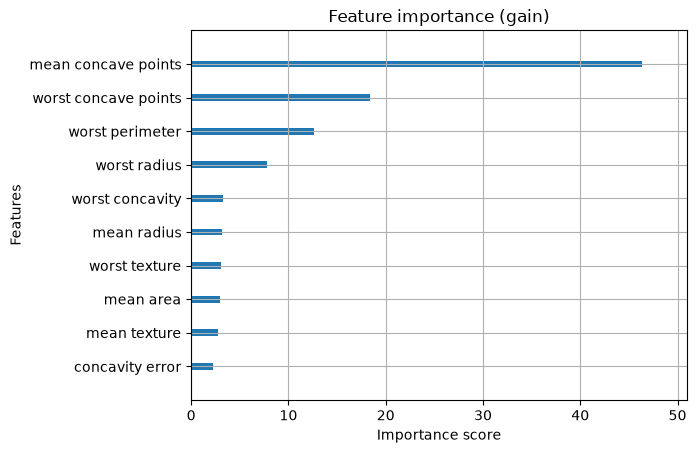

Top 5 most important features:
             feature  importance
 mean concave points    0.386363
worst concave points    0.153053
     worst perimeter    0.104884
        worst radius    0.065252
     worst concavity    0.026850


In [88]:
# Get feature importance
importances = model.feature_importances_
featureImportance = pd.DataFrame({
    "feature": XTrain.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

# Plot feature importance
ax = xgb.plot_importance(model, importance_type="gain", max_num_features=10,
                         show_values=False, title="Feature importance (gain)")
plt.show()

# Print top 5 features
print("Top 5 most important features:")
print(featureImportance.head(5).to_string(index=False))

❓ 4.5 In your own words, give a 2-3 sentence *brief* summary of how XGBoost works.

✅ Answer: XGBoost builds many shallow decision trees one after another. Each new tree is fit to the gradient of the loss, essentially the remaining errors of the current ensemble, and its output is added to the running prediction after being scaled by the learning rate. Regularization (penalties on tree complexity, the shrinkage learning rate, and depth limits) keeps these many small corrections from overfitting.